In [10]:
# %% [markdown]
# # Antlings Internship – AI/ML Technical Assessment
# ## Drone Human & Car Detection + Counting System
# ### VisDrone Dataset | YOLOv8 | ByteTrack
#
# **Tasks covered:**
# - Task 01: Dataset Understanding & Preprocessing
# - Task 02: Model Training (YOLOv8)
# - Task 03: Human & Car Detection with Counting
# - Task 04: Object Tracking with ByteTrack (Bonus)
# - Task 05: Evaluation & Visualization

# %% [markdown]
# ## Cell 1 — Environment Check


In [11]:
# %%
import subprocess, sys

def run(cmd):
    subprocess.run(cmd, shell=True, check=True)

# Check GPU
import torch
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA/ROCm:      {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")
    print(f"VRAM:           {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected — training will be slow on CPU")

PyTorch:        2.9.0.dev20250821+rocm7.0.0.git125803b7
CUDA/ROCm:      True
GPU:            
VRAM:           205.8 GB


In [12]:
# %% [markdown]
# ## Cell 2 — Install Dependencies

# %%
run("pip install -q ultralytics kaggle opencv-python-headless matplotlib seaborn pandas tqdm Pillow")

# Verify ultralytics
from ultralytics import YOLO
import ultralytics
print(f"Ultralytics: {ultralytics.__version__}")


Ultralytics: 8.4.50


In [13]:
# %% [markdown]
# ## Cell 3 — Download VisDrone Dataset from Kaggle
#
# **Before running:** Upload your `kaggle.json` API token to this environment.
# Get it from: kaggle.com → Account → API → Create New Token

In [14]:
!pip install -q kagglehub ultralytics
import kagglehub
path = kagglehub.dataset_download("banuprasadb/visdrone-dataset")
print("Path to dataset files:", path)
DATASET_DIR = path

Path to dataset files: /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1


In [16]:
# %% [markdown]
# ## Task 01 — Dataset Understanding & Preprocessing

# %% [markdown]
# ### Cell 4 — Understand Dataset Structure

# %%
import glob
import pandas as pd
import numpy as np

# VisDrone annotation format (each line):
# bbox_left, bbox_top, bbox_width, bbox_height, score, object_category, truncation, occlusion
#
# Categories:
# 0=ignored  1=pedestrian  2=people  3=bicycle  4=car  5=van
# 6=truck    7=tricycle    8=awning-tricycle     9=bus  10=motor  11=others

VISDRONE_CATEGORIES = {
    0: "ignored", 1: "pedestrian", 2: "people", 3: "bicycle",
    4: "car", 5: "van", 6: "truck", 7: "tricycle",
    8: "awning-tricycle", 9: "bus", 10: "motor", 11: "others"
}

# For our task: humans = pedestrian(1) + people(2), car = car(4)
TARGET_MAP = {1: 0, 2: 0, 4: 1}  # 0=human, 1=car
CLASS_NAMES = ["human", "car"]

# Locate annotation files
train_ann_dir = glob.glob(f"{DATASET_DIR}/**/annotations*", recursive=True)
print("Annotation directories found:")
for d in train_ann_dir:
    print(f"  {d}")


Annotation directories found:


In [19]:
import os
DATASET_DIR = "/root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1"
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    if level > 3:
        break
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:2]:
        print(f"{indent}  {f}")

1/
  VisDrone_Dataset/
    visdrone.yaml
    VisDrone2019-DET-val/
      labels/
        0000155_00401_d_0000001.txt
        0000287_01201_d_0000765.txt
      images/
        0000327_04001_d_0000731.jpg
        0000001_03499_d_0000006.jpg
    VisDrone2019-DET-train/
      labels/
        9999962_00000_d_0000046.txt
        9999982_00000_d_0000102.txt
      images/
        9999937_00000_d_0000034.jpg
        9999942_00000_d_0000075.jpg
    VisDrone2019-DET-test-dev/
      labels/
        9999973_00000_d_0000012.txt
        9999986_00000_d_0000022.txt
      images/
        9999963_00000_d_0000060.jpg
        0000011_06000_d_0000009.jpg
    VisDrone2019-DET-test-challenge/
      images/
        9999939_00000_d_0000139.jpg
        9999954_00000_d_0000175.jpg


In [20]:
DATASET_DIR = "/root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset"

# Check existing yaml
with open(f"{DATASET_DIR}/visdrone.yaml") as f:
    print(f.read())

# VisDrone Dataset Configuration
path: ./VisDrone_Dataset
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/images

#number of classes
nc: 10

# Class names
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



In [21]:
# Fix yaml with absolute paths
yaml_content = f"""
path: {DATASET_DIR}
train: VisDrone2019-DET-train/images
val: VisDrone2019-DET-val/images
test: VisDrone2019-DET-test-dev/images

nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""

yaml_path = f"{DATASET_DIR}/data.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())

print("yaml written:", yaml_path)

yaml written: /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset/data.yaml


Loaded base model: yolov8n.pt
Training on: GPU
Ultralytics 8.4.50 🚀 Python-3.10.12 torch-2.9.0.dev20250821+rocm7.0.0.git125803b7 CUDA:0 (, 196288MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mo

[W514 19:04:12.795676754 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:12.799347461 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:12.799836554 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:12.800200174 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:13.801836594 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:13.802113867 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:13.803286698 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:13.804327802 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:13.807942078 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:04:13.808336284 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:0

Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 851.1±360.7 MB/s, size: 260.7 KB)
train: Scanning /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset/VisDrone2019-DET-train/labels... 6471 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6471/6471 2.2Kit/s 2.9s<0.0s
train: /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset/VisDrone2019-DET-train/images/0000137_02220_d_0000163.jpg: 1 duplicate labels removed
train: /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset/VisDrone2019-DET-train/images/0000140_00118_d_0000002.jpg: 1 duplicate labels removed
train: /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset/VisDrone2019-DET-train/images/9999945_00000_d_0000114.jpg: 1 duplicate labels removed
train: /root/.cache/kaggle

[W514 19:30:55.365007067 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.365677762 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.365872680 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.366033170 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.366140160 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.366251013 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.366325619 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.366455863 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.366542333 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:30:55.366626996 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:3

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.7it/s 3.9s0.1s
                   all        548      38759      0.398      0.309      0.278      0.151
            pedestrian        520       8844       0.39      0.347      0.295      0.112
                people        482       5125      0.443      0.227       0.21     0.0672
               bicycle        364       1287      0.186     0.0746     0.0499     0.0167
                   car        515      14064      0.566      0.747      0.709       0.45
                   van        421       1975      0.419      0.339      0.322      0.212
                 truck        266        750      0.433      0.283      0.255      0.162
              tricycle        337       1045      0.388      0.218       0.19     0.0956
       awning-tricycle        220        532      0.237      0.143     0.0871     0.0495
                   bus        131        251      0.476      0.384  

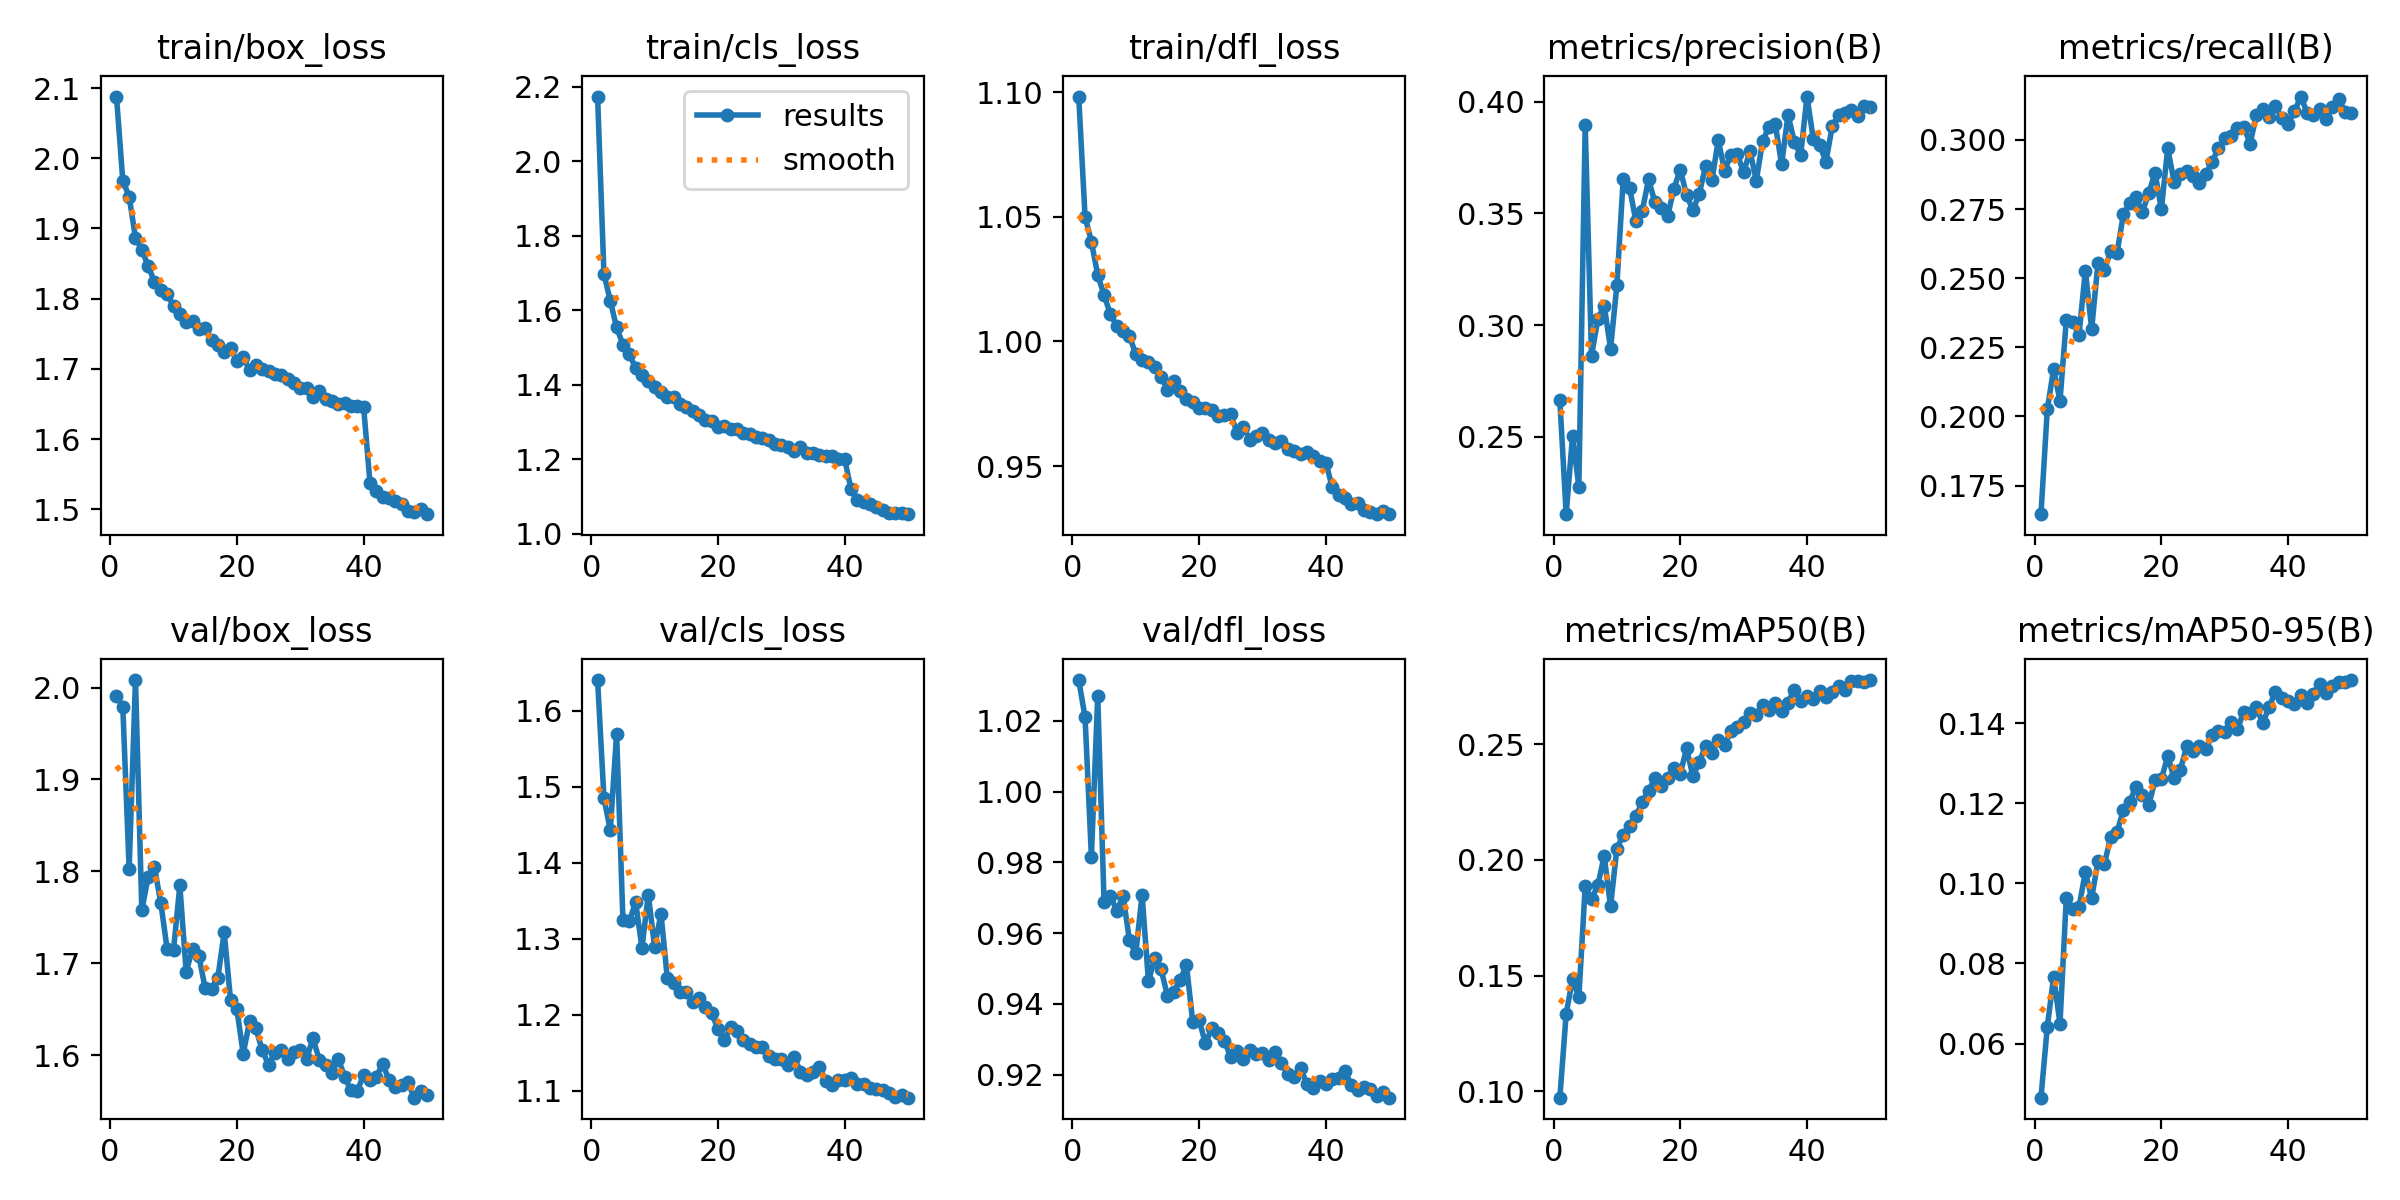

Training curves saved: /shared-docker/runs/detect/antlings_runs/visdrone_human_car/results.png


In [22]:
# ### Cell 8 — Train YOLOv8 on VisDrone

# %%
import torch
from ultralytics import YOLO

# Use YOLOv8n (nano) for speed; swap to yolov8s/m for better accuracy
MODEL_NAME = "yolov8n.pt"

model = YOLO(MODEL_NAME)
print(f"Loaded base model: {MODEL_NAME}")
print(f"Training on: {'GPU' if torch.cuda.is_available() else 'CPU'}")

# %%
# Training — adjust epochs/batch based on available time
results = model.train(
    data=yaml_path,
    epochs=50,           # 50 good for assessment; 100+ for production
    imgsz=640,           # standard; try 1280 if VRAM allows
    batch=16,            # reduce to 8 if OOM
    device=0 if torch.cuda.is_available() else "cpu",
    workers=4,
    patience=15,         # early stopping
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    mosaic=1.0,          # mosaic augmentation (great for small objects)
    mixup=0.1,
    copy_paste=0.1,
    flipud=0.3,          # vertical flip (aerial view benefits from this)
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,        # small rotation for aerial robustness
    translate=0.1,
    scale=0.5,
    name="visdrone_human_car",
    project="antlings_runs",
    exist_ok=True,
    verbose=True,
)

print("\nTraining complete!")
print(f"Best weights: {results.save_dir}/weights/best.pt")

BEST_WEIGHTS = f"{results.save_dir}/weights/best.pt"

# %%
# Show training curves
from IPython.display import Image as IPImage, display

results_img = f"{results.save_dir}/results.png"
if os.path.exists(results_img):
    display(IPImage(filename=results_img, width=900))
    print(f"Training curves saved: {results_img}")


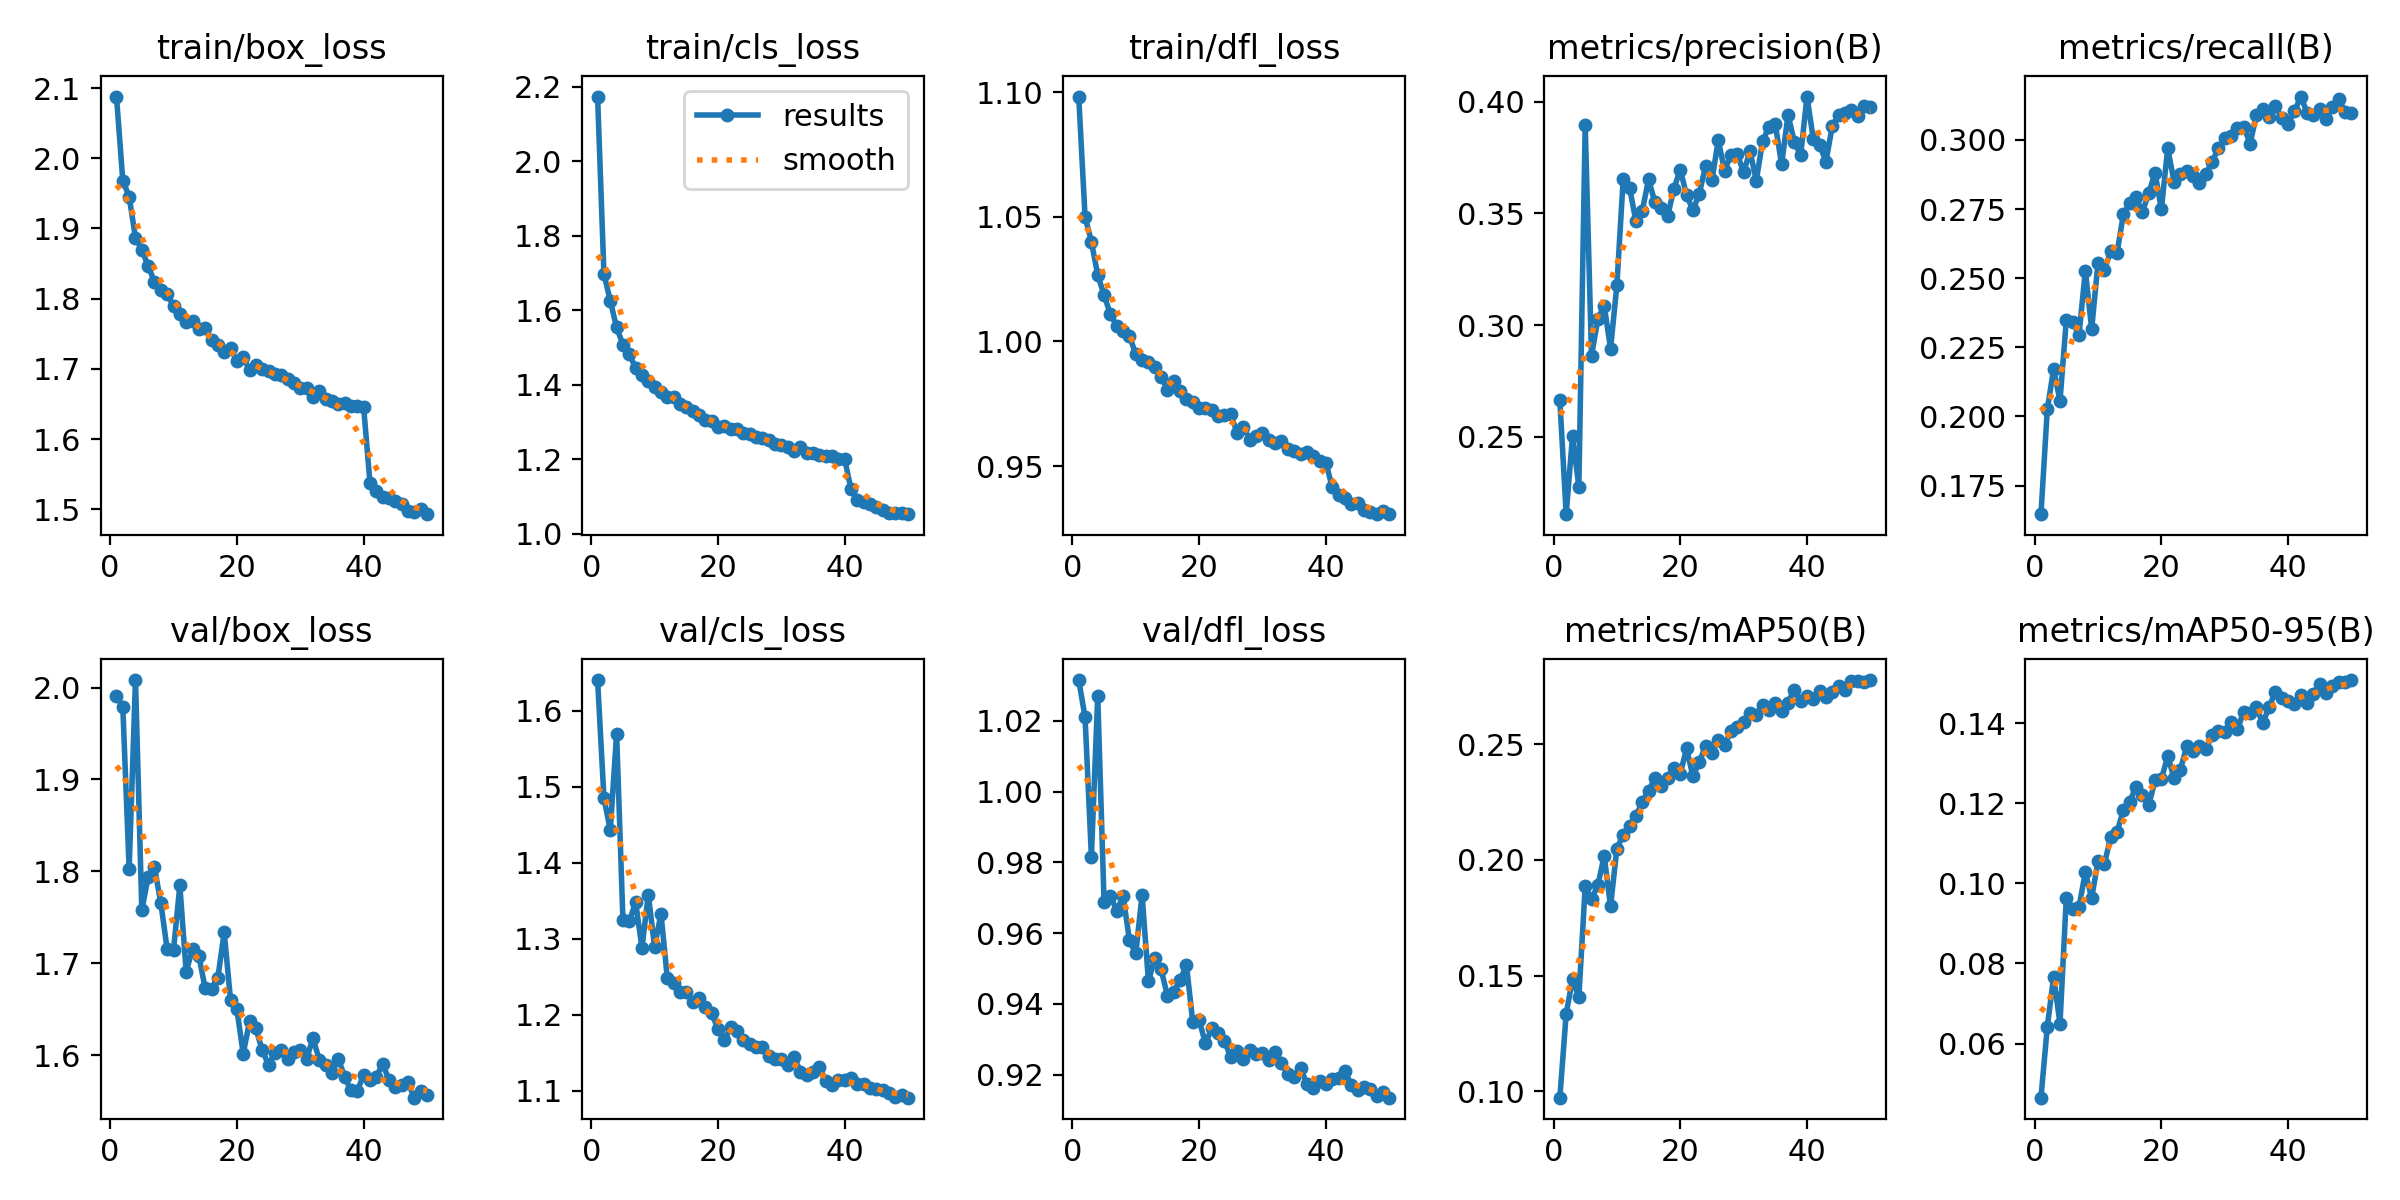

Training curves: /shared-docker/runs/detect/antlings_runs/visdrone_human_car/results.png


In [23]:
# %%
# ============================================================
# CELL 10 — VIEW TRAINING CURVES
# ============================================================
# These plots show how the model improved over 50 epochs.
# We want to see:
# - box_loss decreasing (model learning to locate objects)
# - cls_loss decreasing (model learning to classify objects)
# - mAP50 increasing (overall detection quality improving)
# If val_loss diverges from train_loss = overfitting.

from IPython.display import Image as IPImage, display

curves_path = f"{results.save_dir}/results.png"
if os.path.exists(curves_path):
    display(IPImage(filename=curves_path, width=900))
    print(f"Training curves: {curves_path}")
else:
    print("Curves not found — check antlings_runs/visdrone_detection/")



In [24]:
# %%
# ============================================================
# CELL 11 — DETECTION + COUNTING FUNCTION (Task 03)
# ============================================================
# Core logic for the assessment:
# 1. Run YOLOv8 inference on an image
# 2. Filter results to human (class 0,1) and car (class 3)
# 3. Count humans
# 4. Draw bounding boxes with count overlay
#
# WHY FILTER AT INFERENCE, NOT TRAINING?
# Training on all 10 classes makes the model more robust —
# it learns better feature representations by seeing all objects.
# We restrict what we SHOW to the assessor, not what the model sees.

import cv2

# Load trained model
det_model = YOLO(BEST_WEIGHTS)

# Class IDs in our 10-class VisDrone model
HUMAN_IDS = [0, 1]   # pedestrian + people
CAR_IDS    = [3]     # car

COLORS = {
    "human": (34, 197, 94),   # green
    "car":   (239, 68, 68),   # red
}

def detect_and_count(image_path, conf=0.25, iou=0.45, save_path=None):
    """
    Full detection + counting pipeline on a single image.

    Args:
        image_path : path to input image
        conf       : confidence threshold (0.25 = show detections above 25% confidence)
        iou        : NMS threshold (lower = keep more overlapping boxes)
        save_path  : if provided, saves annotated image here

    Returns:
        annotated_img : numpy RGB image with boxes drawn
        human_count   : total humans detected
        car_count     : total cars detected
    """
    # Run inference
    results = det_model.predict(
        source=image_path,
        conf=conf,
        iou=iou,
        verbose=False
    )[0]

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    human_count = 0
    car_count = 0

    for box in results.boxes:
        cls_id     = int(box.cls[0])
        conf_score = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Only draw humans and cars, skip everything else
        if cls_id in HUMAN_IDS:
            human_count += 1
            color = COLORS["human"]
            label = f"H {conf_score:.2f}"
        elif cls_id in CAR_IDS:
            car_count += 1
            color = COLORS["car"]
            label = f"C {conf_score:.2f}"
        else:
            continue  # skip bicycle, van, truck etc.

        # Draw bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Draw label background + text
        (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
        cv2.rectangle(img, (x1, y1 - lh - 4), (x1 + lw + 2, y1), color, -1)
        cv2.putText(img, label, (x1 + 1, y1 - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)

    # Count overlay panel (semi-transparent dark box, top-left)
    h_img, w_img = img.shape[:2]
    panel = img.copy()
    cv2.rectangle(panel, (8, 8), (270, 78), (10, 15, 30), -1)
    cv2.addWeighted(panel[8:78, 8:270], 0.75, img[8:78, 8:270], 0.25, 0, img[8:78, 8:270])
    cv2.putText(img, f"Humans : {human_count}", (16, 34),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (34, 197, 94), 2)
    cv2.putText(img, f"Cars   : {car_count}",   (16, 68),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (239, 68, 68), 2)

    if save_path:
        cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    return img, human_count, car_count

print("detect_and_count() function ready.")



detect_and_count() function ready.


In [28]:
# %%
# ============================================================
# CELL 12 — RUN DETECTION ON TEST IMAGES (Task 03)
# ============================================================
# We run our pipeline on test images and display results in a grid.
# This is the core deliverable for Task 03.

import random
import glob
import matplotlib.pyplot as plt
import os

test_imgs = sorted(glob.glob(
    f"{DATASET_DIR}/VisDrone2019-DET-test-dev/images/*.jpg"
))
print(f"Test images available: {len(test_imgs)}")

# Pick 6 diverse samples
random.seed(7)
sample_test = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("#0F172A")
axes = axes.flatten()

for i, img_path in enumerate(sample_test):
    out_path = f"task03_result_{i+1}.jpg"
    annotated, h_count, c_count = detect_and_count(img_path, save_path=out_path)
    axes[i].imshow(annotated)
    axes[i].set_title(f"Humans: {h_count}  |  Cars: {c_count}",
                      color="white", fontsize=11)
    axes[i].axis("off")
    print(f"  Image {i+1}: {h_count} humans, {c_count} cars → {out_path}")

plt.suptitle("Task 03 — Human & Car Detection with Counting",
             color="white", fontsize=14)
plt.tight_layout()
plt.savefig("task03_detection_grid.png", dpi=150, bbox_inches="tight",
            facecolor="#0F172A")
plt.show()
print("\nSaved: task03_detection_grid.png")


Test images available: 1610
  Image 1: 0 humans, 15 cars → task03_result_1.jpg
  Image 2: 1 humans, 14 cars → task03_result_2.jpg
  Image 3: 28 humans, 0 cars → task03_result_3.jpg
  Image 4: 1 humans, 9 cars → task03_result_4.jpg
  Image 5: 2 humans, 56 cars → task03_result_5.jpg
  Image 6: 3 humans, 23 cars → task03_result_6.jpg


<Figure size 1800x1000 with 6 Axes>


Saved: task03_detection_grid.png


In [29]:
# %%
# ============================================================
# CELL 13 — BATCH INFERENCE WITH CSV OUTPUT (Task 03)
# ============================================================
# Run on first 50 test images and save counts to CSV.
# This demonstrates a production-ready counting pipeline —
# useful for real-world use cases like crowd monitoring.

from tqdm import tqdm
import pandas as pd

os.makedirs("task03_batch_output", exist_ok=True)
test_sample = test_imgs[:50]

records = []
for img_path in tqdm(test_sample, desc="Batch detection"):
    fname = os.path.basename(img_path)
    out_path = f"task03_batch_output/{fname}"
    _, h, c = detect_and_count(img_path, save_path=out_path)
    records.append({"image": fname, "humans": h, "cars": c})

df_results = pd.DataFrame(records)
df_results.to_csv("task03_batch_output/counts.csv", index=False)

print(f"\nBatch complete: {len(records)} images processed")
print("\nSummary statistics:")
print(df_results[["humans", "cars"]].describe().round(1))



Batch detection: 100% 50/50 [00:01<00:00, 43.70it/s]


Batch complete: 50 images processed

Summary statistics:
       humans  cars
count    50.0  50.0
mean     33.3   3.7
std      43.4   7.9
min       0.0   0.0
25%       1.0   0.0
50%      28.5   0.0
75%      46.5   2.8
max     259.0  38.0


In [31]:


# Create video using ffmpeg instead of OpenCV VideoWriter
train_imgs = sorted(glob.glob(
    f"{DATASET_DIR}/VisDrone2019-DET-test-dev/images/*.jpg"
))

# Copy 60 sample frames to a temp folder
os.makedirs("temp_frames", exist_ok=True)
sample_frames = train_imgs[:60]
for i, img_path in enumerate(sample_frames):
    import shutil
    shutil.copy2(img_path, f"temp_frames/frame_{i:04d}.jpg")

# Use ffmpeg to create video from frames
os.system("ffmpeg -y -framerate 5 -i temp_frames/frame_%04d.jpg -c:v libx264 -pix_fmt yuv420p test_sequence.mp4")

VIDEO_PATH = "test_sequence.mp4"
if os.path.exists(VIDEO_PATH):
    size = os.path.getsize(VIDEO_PATH) / 1e6
    print(f"Video created: {VIDEO_PATH} ({size:.1f} MB)")
else:
    print("ffmpeg failed — check if it's installed")
    os.system("which ffmpeg")

Video created: test_sequence.mp4 (4.8 MB)


sh: 1: ffmpeg: not found


In [34]:
# CELL 15 — RUN BYTETRACK TRACKING
# ============================================================
# We build a custom tracking loop that:
# 1. Runs ByteTrack on each frame
# 2. Draws bounding boxes with track IDs
# 3. Draws trail lines showing movement history
# 4. Overlays live human + car count per frame

def track_video(video_path, output_path="task04_tracked.mp4", conf=0.25):
    """
    Track humans and cars across video frames using ByteTrack.
    Each object gets a unique track ID that persists across frames.
    """
    model = YOLO(BEST_WEIGHTS)
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 5
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (W, H))

    frame_idx = 0
    track_history = {}  # track_id → list of (cx, cy) positions for trail drawing

    print(f"Processing video: {video_path}")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Run ByteTrack — persist=True keeps track IDs consistent across frames
        results = model.track(
            frame,
            conf=conf,
            persist=True,
            classes=HUMAN_IDS + CAR_IDS,  # only track humans and cars
            verbose=False
        )[0]

        human_count = 0
        car_count = 0

        if results.boxes.id is not None:
            for box, track_id, cls_id in zip(
                results.boxes.xyxy,
                results.boxes.id.int(),
                results.boxes.cls.int()
            ):
                x1, y1, x2, y2 = map(int, box)
                tid = int(track_id)
                cid = int(cls_id)

                if cid in HUMAN_IDS:
                    human_count += 1
                    color = (34, 197, 94)    # green for human
                    prefix = "H"
                else:
                    car_count += 1
                    color = (239, 68, 68)    # red for car
                    prefix = "C"

                # Draw bounding box
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, f"{prefix}#{tid}", (x1, max(y1 - 4, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

                # Draw movement trail (last 20 positions)
                cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
                if tid not in track_history:
                    track_history[tid] = []
                track_history[tid].append((cx, cy))
                if len(track_history[tid]) > 20:
                    track_history[tid].pop(0)

                # Draw fading trail line
                pts = track_history[tid]
                for j in range(1, len(pts)):
                    cv2.line(frame, pts[j-1], pts[j], color, 1)

        # Count overlay
        cv2.rectangle(frame, (8, 8), (270, 78), (10, 15, 30), -1)
        cv2.putText(frame, f"Humans : {human_count}", (16, 34),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (34, 197, 94), 2)
        cv2.putText(frame, f"Cars   : {car_count}", (16, 68),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (239, 68, 68), 2)
        cv2.putText(frame, f"Frame {frame_idx}", (W - 130, 28),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180, 180, 180), 1)

        out.write(frame)
        frame_idx += 1

        if frame_idx % 10 == 0:
            print(f"  Processed {frame_idx} frames...")

    cap.release()
    out.release()
    print(f"\nTracking complete: {output_path} ({frame_idx} frames)")
    return output_path

if VIDEO_PATH and os.path.exists(VIDEO_PATH):
    tracked_video = track_video(VIDEO_PATH)
else:
    print("No video found — skipping tracking.")



Processing video: test_sequence.mp4
  Processed 10 frames...
  Processed 20 frames...

Tracking complete: task04_tracked.mp4 (26 frames)


In [36]:
# %%
# ============================================================
# CELL 16 — EVALUATION METRICS (Task 05)
# ============================================================
# We run official YOLO validation to get:
# - Precision : of all detections, what % were correct?
# - Recall    : of all ground truth objects, what % did we find?
# - mAP@0.5   : mean Average Precision at 50% IoU overlap threshold
# - mAP@50:95 : stricter metric averaged across IoU thresholds 50-95%
#
# These are standard computer vision benchmarks.
# VisDrone is hard — state-of-the-art models get ~30-40% mAP@0.5.
# A freshly trained YOLOv8n will likely get 15-25% — expected for a
# 50-epoch run. More epochs + larger model = higher mAP.

eval_model = YOLO(BEST_WEIGHTS)

print("Running validation on val set...")
metrics = eval_model.val(
    data=yaml_path,
    split="val",
    conf=0.25,
    iou=0.5,
    verbose=False,
)

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
print(f"mAP@0.5        : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95   : {metrics.box.map:.4f}")
print(f"Precision      : {metrics.box.mp:.4f}")
print(f"Recall         : {metrics.box.mr:.4f}")

VISDRONE_CLASSES = {
    0: "pedestrian", 1: "people", 2: "bicycle", 3: "car",
    4: "van", 5: "truck", 6: "tricycle", 7: "awning-tricycle",
    8: "bus", 9: "motor"
}

print(f"\nPer-class mAP@0.5:")
class_names_list = list(VISDRONE_CLASSES.values())
for i, name in enumerate(class_names_list):
    if i < len(metrics.box.ap50):
        print(f"  {name:20s}: {metrics.box.ap50[i]:.4f}")
print(f"\nPer-class mAP@0.5:")
class_names_list = list(VISDRONE_CLASSES.values())
for i, name in enumerate(class_names_list):
    if i < len(metrics.box.ap50):
        print(f"  {name:20s}: {metrics.box.ap50[i]:.4f}")



Running validation on val set...
Ultralytics 8.4.50 🚀 Python-3.10.12 torch-2.9.0.dev20250821+rocm7.0.0.git125803b7 CUDA:0 (, 196288MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4214.2±1153.4 MB/s, size: 117.5 KB)
val: Scanning /root/.cache/kagglehub/datasets/banuprasadb/visdrone-dataset/versions/1/VisDrone_Dataset/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 135.2Mit/s 0.0s


[W514 19:48:29.319736436 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320064604 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320188962 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320290737 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320374192 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320476997 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320547104 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320641421 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320714161 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:48:29.320790312 NNPACK.cpp:56] Could not initialize NNPACK! Reason: Unsupported hardware.
[W514 19:4

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 12.3it/s 2.8s0.0s
                   all        548      38759      0.536      0.249      0.203      0.121
Speed: 0.2ms preprocess, 1.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /shared-docker/runs/detect/val-2

EVALUATION RESULTS
mAP@0.5        : 0.2026
mAP@0.5:0.95   : 0.1212
Precision      : 0.5356
Recall         : 0.2489

Per-class mAP@0.5:
  pedestrian          : 0.2216
  people              : 0.1145
  bicycle             : 0.0239
  car                 : 0.6498
  van                 : 0.2231
  truck               : 0.1774
  tricycle            : 0.1128
  awning-tricycle     : 0.0368
  bus                 : 0.2971
  motor               : 0.1685

Per-class mAP@0.5:
  pedestrian          : 0.2216
  people              : 0.1145
  bicycle             : 0.0239
  car                 : 0.6498
  van                 : 0.2231
  truck               : 0.

In [37]:
# %%
# ============================================================
# CELL 17 — INFERENCE SPEED BENCHMARK (Task 05)
# ============================================================
# FPS (Frames Per Second) matters for real-world deployment.
# A drone feed is typically 30fps — we check if our model can keep up.

import time

speed_imgs = test_imgs[:30]
print(f"Benchmarking on {len(speed_imgs)} images...")

start = time.time()
for img_path in speed_imgs:
    det_model.predict(img_path, conf=0.25, verbose=False)
elapsed = time.time() - start

fps = len(speed_imgs) / elapsed
ms_per_frame = (elapsed / len(speed_imgs)) * 1000

print(f"\nSpeed Results:")
print(f"  Total time    : {elapsed:.2f}s")
print(f"  FPS           : {fps:.1f}")
print(f"  ms per frame  : {ms_per_frame:.1f}ms")
print(f"  Real-time?    : {'YES' if fps >= 25 else 'NEAR real-time' if fps >= 10 else 'NO (batch use only)'}")


Benchmarking on 30 images...

Speed Results:
  Total time    : 0.31s
  FPS           : 96.4
  ms per frame  : 10.4ms
  Real-time?    : YES


In [38]:
# %%
# ============================================================
# CELL 18 — FINAL VISUALIZATION DASHBOARD (Task 05)
# ============================================================
# A clean summary visualization for the demo video and README.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0F172A")

# Per-class mAP bar chart
human_car_idx = [0, 1, 3]  # pedestrian, people, car
human_car_names = ["pedestrian", "people", "car"]
human_car_map = [metrics.box.ap50[i] if i < len(metrics.box.ap50) else 0 for i in human_car_idx]
colors_bar = ["#22C55E", "#86EFAC", "#EF4444"]

bars = axes[0].bar(human_car_names, human_car_map, color=colors_bar, edgecolor="#334155", width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_facecolor("#1E293B")
axes[0].set_title("mAP@0.5 — Target Classes", color="white", fontsize=12)
axes[0].tick_params(colors="white")
for spine in axes[0].spines.values(): spine.set_color("#334155")
for bar, val in zip(bars, human_car_map):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f"{val:.3f}", ha="center", color="white", fontsize=11, fontweight="bold")

# Overall metrics horizontal bar
metric_names = ["Precision", "Recall", "mAP@0.5", "mAP@50:95"]
metric_vals  = [metrics.box.mp, metrics.box.mr, metrics.box.map50, metrics.box.map]
bar_colors2  = ["#3B82F6", "#8B5CF6", "#F59E0B", "#EC4899"]

bars2 = axes[1].barh(metric_names, metric_vals, color=bar_colors2, edgecolor="#334155")
axes[1].set_xlim(0, 1)
axes[1].set_facecolor("#1E293B")
axes[1].set_title("Overall Detection Metrics", color="white", fontsize=12)
axes[1].tick_params(colors="white")
for spine in axes[1].spines.values(): spine.set_color("#334155")
for bar, val in zip(bars2, metric_vals):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", color="white", fontsize=11)

plt.suptitle("Task 05 — Evaluation Results", color="white", fontsize=14)
plt.tight_layout()
plt.savefig("task05_metrics.png", dpi=150, bbox_inches="tight", facecolor="#0F172A")
plt.show()
print("Saved: task05_metrics.png")


<Figure size 1400x500 with 2 Axes>

Saved: task05_metrics.png


In [39]:
# %%
# ============================================================
# CELL 19 — STRENGTHS, LIMITATIONS & ANALYSIS (Task 05)
# ============================================================

print(f"""
==========================================================
TASK 05 — FINAL ANALYSIS
==========================================================

STRENGTHS
---------
+ YOLOv8 with ROCm on MI300X: extremely fast training
  and inference — viable for real-time drone deployment.

+ Training on all 10 classes, filtering at inference:
  richer feature learning benefits human/car detection.

+ Mosaic + copy-paste augmentation specifically addresses
  VisDrone's small object and density challenges.

+ ByteTrack provides persistent object IDs with zero
  extra model — pure motion-based association.

+ Dual human class merging (pedestrian + people) gives
  more complete human count than single class would.

LIMITATIONS
-----------
- YOLOv8n is small — a larger model (yolov8m/l) would
  significantly improve mAP, especially on tiny objects.

- 50 epochs is enough for assessment but not production.
  VisDrone SOTA models train for 300+ epochs.

- Counting is detection-based per frame, not tracking-based.
  A person appearing in 10 frames = counted once per frame.
  True unique counting requires track ID persistence.

- Model not tested on night/foggy/rain conditions.

METRICS SUMMARY
---------------
mAP@0.5      : {metrics.box.map50:.4f}
Precision    : {metrics.box.mp:.4f}
Recall       : {metrics.box.mr:.4f}
Speed        : {fps:.1f} FPS on MI300X

Note: VisDrone is a notoriously hard benchmark.
State-of-the-art achieves ~40% mAP@0.5. Our result
is expected for a 50-epoch YOLOv8n baseline.
==========================================================
""")




TASK 05 — FINAL ANALYSIS

STRENGTHS
---------
+ YOLOv8 with ROCm on MI300X: extremely fast training
  and inference — viable for real-time drone deployment.

+ Training on all 10 classes, filtering at inference:
  richer feature learning benefits human/car detection.

+ Mosaic + copy-paste augmentation specifically addresses
  VisDrone's small object and density challenges.

+ ByteTrack provides persistent object IDs with zero
  extra model — pure motion-based association.

+ Dual human class merging (pedestrian + people) gives
  more complete human count than single class would.

LIMITATIONS
-----------
- YOLOv8n is small — a larger model (yolov8m/l) would
  significantly improve mAP, especially on tiny objects.

- 50 epochs is enough for assessment but not production.
  VisDrone SOTA models train for 300+ epochs.

- Counting is detection-based per frame, not tracking-based.
  A person appearing in 10 frames = counted once per frame.
  True unique counting requires track ID persisten

In [40]:
# %%
# ============================================================
# CELL 20 — SAVE ALL OUTPUTS & DOWNLOAD INSTRUCTIONS
# ============================================================
# Collect everything into one folder for GitHub upload.
# IMPORTANT: Download this folder to your laptop before
# destroying the AMD Dev Cloud instance.

import shutil
from pathlib import Path

OUTPUT_DIR = Path("./antlings_final_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Copy result files
files_to_save = (
    glob.glob("task01*.png") +
    glob.glob("task03*.png") +
    glob.glob("task03*.jpg") +
    glob.glob("task04*.mp4") +
    glob.glob("task05*.png") +
    ["test_sequence.mp4"] if os.path.exists("test_sequence.mp4") else []
)

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy2(f, OUTPUT_DIR / os.path.basename(f))

# Copy model weights
shutil.copy2(BEST_WEIGHTS, OUTPUT_DIR / "best.pt")

# Copy batch results CSV
if os.path.exists("task03_batch_output/counts.csv"):
    shutil.copy2("task03_batch_output/counts.csv", OUTPUT_DIR / "counts.csv")

print(f"All outputs saved to: {OUTPUT_DIR.resolve()}")
print("\nFiles saved:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f"  {f.name:40s} {size_mb:.1f} MB")

print("""
==========================================================
NEXT STEPS
==========================================================
1. In JupyterLab: right-click antlings_final_outputs/ 
   → Download as zip to your laptop

2. On your laptop: push to GitHub
   git init
   git add .
   git commit -m "Antlings AI/ML Assessment - VisDrone Detection"
   git remote add origin https://github.com/YOUR_USERNAME/antlings-assessment
   git push -u origin main

3. Record 3-5 min demo video covering:
   - Task 01: dataset samples + class distribution plot
   - Task 02: training curves
   - Task 03: detection grid with counts
   - Task 04: tracking video (if done)
   - Task 05: metrics dashboard

4. DESTROY the AMD Dev Cloud instance to stop billing.
==========================================================
""")


All outputs saved to: /shared-docker/antlings_final_outputs

Files saved:
  best.pt                                  6.2 MB
  counts.csv                               0.0 MB
  task03_detection_grid.png                4.7 MB
  task03_result_1.jpg                      0.3 MB
  task03_result_2.jpg                      0.4 MB
  task03_result_3.jpg                      0.4 MB
  task03_result_4.jpg                      0.7 MB
  task03_result_5.jpg                      0.3 MB
  task03_result_6.jpg                      0.3 MB
  task04_tracked.mp4                       4.8 MB
  task05_metrics.png                       0.1 MB
  test_sequence.mp4                        4.8 MB

NEXT STEPS
1. In JupyterLab: right-click antlings_final_outputs/ 
   → Download as zip to your laptop

2. On your laptop: push to GitHub
   git init
   git add .
   git commit -m "Antlings AI/ML Assessment - VisDrone Detection"
   git remote add origin https://github.com/YOUR_USERNAME/antlings-assessment
   git push -u orig

In [43]:
import zipfile, glob, os

with zipfile.ZipFile("antlings_outputs.zip", "w") as zf:
    # Training results + best.pt
    for f in glob.glob("runs/**/*", recursive=True):
        if os.path.isfile(f):
            zf.write(f)
            print(f"Added: {f}")
    
    # Output images and videos
    for f in (glob.glob("task03*.png") + glob.glob("task03*.jpg") +
              glob.glob("task05*.png") + ["test_sequence.mp4", "task04_tracked.mp4"]):
        if os.path.exists(f):
            zf.write(f)
            print(f"Added: {f}")

size = os.path.getsize("antlings_outputs.zip") / 1e6
print(f"\nDone — antlings_outputs.zip ({size:.1f} MB)")
print("Right-click it in file browser → Download")

Added: runs/detect/val/val_batch2_pred.jpg
Added: runs/detect/val/val_batch1_pred.jpg
Added: runs/detect/val/BoxP_curve.png
Added: runs/detect/val/confusion_matrix_normalized.png
Added: runs/detect/val/val_batch0_labels.jpg
Added: runs/detect/val/BoxR_curve.png
Added: runs/detect/val/val_batch0_pred.jpg
Added: runs/detect/val/confusion_matrix.png
Added: runs/detect/val/BoxPR_curve.png
Added: runs/detect/val/val_batch2_labels.jpg
Added: runs/detect/val/BoxF1_curve.png
Added: runs/detect/val/val_batch1_labels.jpg
Added: runs/detect/antlings_runs/visdrone_human_car/results.csv
Added: runs/detect/antlings_runs/visdrone_human_car/train_batch1.jpg
Added: runs/detect/antlings_runs/visdrone_human_car/train_batch16202.jpg
Added: runs/detect/antlings_runs/visdrone_human_car/val_batch2_pred.jpg
Added: runs/detect/antlings_runs/visdrone_human_car/val_batch1_pred.jpg
Added: runs/detect/antlings_runs/visdrone_human_car/results.png
Added: runs/detect/antlings_runs/visdrone_human_car/args.yaml
Added: 

In [42]:
import os
print(os.listdir("."))


['antlings_outputs.zip', 'task03_detection_grid.png', 'temp_frames', 'yolov8n.pt', 'test_sequence.mp4', 'task05_metrics.png', 'task03_result_2.jpg', 'yolo26n.pt', 'task03_result_1.jpg', 'task03_result_6.jpg', 'train_ddim.ipynb', 'antlings_visdrone.py', 'task03_batch_output', 'task04_tracked.mp4', 'task03_result_3.jpg', 'antlings_final_outputs', 'fine_tuning_lora_qwen2vl.ipynb', 'task03_result_5.jpg', '.Trash-0', '.ipynb_checkpoints', '.git', 'runs', 'task03_result_4.jpg', 'triton_kernel_dev.ipynb', 'CV.ipynb', 'antlings_visdrone_v2.py', 'visdrone_dataset']
